# 02 Symbolic Regression with KANs

In [49]:
import torch
from kan import KAN, create_dataset

## Target function

$f(x, y) = \exp(\sin(\pi x) + y^2)$

In [50]:
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = create_dataset(f, n_var=2)

## Train a KAN

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.79e-02 | test_loss: 1.87e-02 | reg: 7.48e+00 | : 100%|█| 50/50 [00:06<00:00,  7.22it


saving model version 0.1


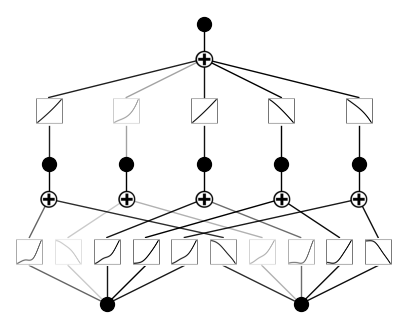

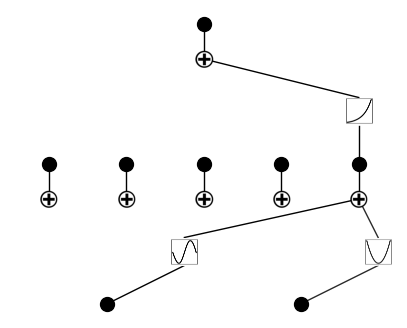

In [51]:
model = KAN(width=[2, 5, 1], grid=3, k=3, seed=42)

model(dataset['train_input'])
model.plot()

model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001);
model.plot()

## Prune the network

saving model version 0.2


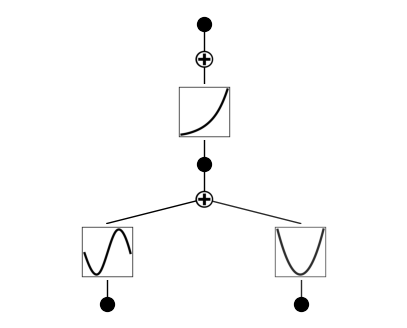

In [52]:
model = model.prune()
model.plot()

## Continue training the pruned network

| train_loss: 1.65e-02 | test_loss: 1.71e-02 | reg: 7.57e+00 | : 100%|█| 50/50 [00:01<00:00, 38.18it


saving model version 0.3


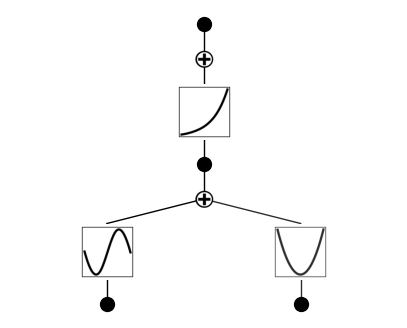

In [53]:
results = model.fit(dataset, opt="LBFGS", steps=50, lr=1.0, lamb=0.01)
model.plot()

## Attempt symbolic regression

`auto_symbolic()` tries to fit known symbolic functions (sin, cos, exp, x^2, etc.) for each learned activation function.

In [54]:
lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
model.auto_symbolic()

fixing (0,0,0) with sin, r2=0.9999004006385803, c=2
fixing (0,1,0) with x^2, r2=0.9999977350234985, c=2
fixing (1,0,0) with exp, r2=0.9999704360961914, c=2
saving model version 0.4


In [55]:
# Display the recovered symbolic formula
formula = model.symbolic_formula(var=['x1', 'x2'])[0][0]
print("Recovered symbolic formula:", formula)

Recovered symbolic formula: 0.965721524149933*exp(0.0612152960455026*(4.0461597442627*x2 + 0.000880001054611057)**2 + 1.02643464376047*sin(3.13712000846863*x1 - 0.00104000116698444)) + 0.0398751497268677


## Retrain with symbolic constraints

In [56]:
results = model.fit(dataset, opt="LBFGS", steps=50, lr=1.0)
print(f"Final test RMSE: {results['test_loss'][-1]:.6f}")

| train_loss: 2.60e-07 | test_loss: 2.65e-07 | reg: 0.00e+00 | : 100%|█| 50/50 [00:01<00:00, 45.87it

saving model version 0.5
Final test RMSE: 0.000000


In [58]:
# Show the final symbolic formula
formula = model.symbolic_formula(var=['x1', 'x2'])[0][0]
print(f"Final formula: {formula}")

Final formula: 0.999999863129098*exp(0.0610849513768477*(4.04606533050537*x2 + 4.61270133200742e-10)**2 + 1.00000002829697*sin(3.14159274101257*x1 + 3.35640351067923e-8)) + 1.69983067621615e-7
